# Descriptors and QSAR/QSPR

In this lab we will apply our knowledge in supervised learning to a real world dataset. Remember, in supervised learning the algorithm is given both features and target data for each observation. In pharmaceutical bioinformatics, typical features may be numerical descriptions of chemical attributes (PhysChem descriptors) or structural features. Target data can be some biological/chemical properties of the molecules, determined by their structure. For instance, we may study how structural changes influence ADMET properties (absorption, distribution, metabolism, excretion, and toxicity) or the interaction affinity between the molecule and some receptor protein. In this exercise we will apply linear regression, partial least-squares (PLS), Support Vector Machine (SVM) and Random Forest models to predict aqueous solubility of a series of molecules. If you have time you can try out additional learning methods as well.

We will be using RDKit for the cheminformatics (see [RDKit GettingStartedInPython](https://www.rdkit.org/docs/GettingStartedInPython.html) for a "beginners guide"), when for instance calculating the descriptors of a molecule. There are a multitude of different descriptors to choose from, typically you will have to try different types and see what works best for you particular data. In this lab we will try out two types of molecular fingerprints (Morgan fingerprints and RDKits own fingerprints) and a set of Physico-Chemical (PhysChem) descriptors.

Run through the cells one by one, make sure you understand what is going on and make appropriate changes when needed. Ask if you do not understand parts of the code or the reasoning behind it. This lab is mostly running existing code, but you are encouraged to change the code and try things as you go along.

First we will load in the data set, have a quick look at it and do some basic cleaning steps. In part 2 we will use molecular fingerprints for similiarity maching - a common technique in cheminformatics (albeit usually with a different goal) and try a naive approach of prediction using k-NN. In part 3 we will use the fingerprints with some standard ML algorithms, and in part 4 we will calculate a set of PhysChem descriptors and evaluate those. If time permits, you can experiment on your own with other descriptors and/or learning algorithms.

**DO NOT CHANGE THE VARIABLE NAMES IN THE TODO SECTION, AS THEY ARE USED FOR GRADING THE ASSIGNMENT.**

**Required packages to run**
- rdkit
- scikit-learn 
- pandas
- matplotlib

**Note: RDKit is not available by default, so we need to install it**. You may need to restart the kernel for the download to take effect. 

In [28]:
# Install RDKit 
!pip install rdkit

## 1. Aquire the data set
We will explore a dataset of aqueous solubility of 1142 diverse chemical compounds. You may look at the referenced publication [ESOL: Estimating Aqueous Solubility Directly from Molecular Structure](http://pubs.acs.org/doi/abs/10.1021/ci034243x) to find out more about the original data (it's published as Supporting Info) and the conducted study. In this paper they used a set of eight PhysChem descriptors and applied Linear Regression and found that in particular four of them were the ones most significant in the generated models. Here we will evaluate their results and see if we can improve upon them. 

This first cell loads in the required packages and define a `standardize` function that takes a SMILES text string and generates an RDKit Mol object and do some standard normalization of the molecule.

A SMILES string (like "c1ccccc1") is a simple text representation of a molecule (in this case, benzene), and an RDKit Mol object is the computer-readable molecular structure that RDKit generates from that SMILES string for further analysis and visualization.

In [29]:
%matplotlib inline

import os
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.cross_decomposition import PLSRegression

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, PandasTools, Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Draw import IPythonConsole

# Configure the logging - RDKit is rather verbose..
from rdkit import RDLogger
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)


fig_size = (8,6)

# Loading and standardization method for SMILES -> RDKit molecule object
normalizer = rdMolStandardize.Normalizer()

def standardize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mol = rdMolStandardize.FragmentParent(mol)
        mol = rdMolStandardize.Cleanup(mol)
        mol = normalizer.normalize(mol)
    return mol

shared_data_dir = str(Path(os.environ["SHARED_DATA_DIR"]))

### 1.1 Load data
Now we will load the data, stored in a CSV format and save it in a Pandas DataFrame. *You may have to change the filepath according to your directory layout*.

In [30]:
solu_df = pd.read_csv(shared_data_dir + "/solubility.csv")

# Print an overview of what's in the pandas object
solu_df

,Compound.ID,measured.log.solubility.mol.L.,ESOL.predicted.log.solubility.mol.L.,SMILES
0,"1,1,1,2-Tetrachloroethane",-2.180,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.000,-2.232,CC(Cl)(Cl)Cl
2,"1,1,2,2-Tetrachloroethane",-1.740,-2.549,ClC(Cl)C(Cl)Cl
3,"1,1,2-Trichloroethane",-1.480,-1.961,ClCC(Cl)Cl
4,"1,1,2-Trichlorotrifluoroethane",-3.040,-3.077,FC(F)(Cl)C(F)(Cl)Cl
...,...,...,...,...
1137,vamidothion,1.144,-1.446,CNC(=O)C(C)SCCSP(=O)(OC)(OC)
1138,Vinclozolin,-4.925,-4.377,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C
1139,Warfarin,-3.893,-3.913,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O
1140,Xipamide,-3.790,-3.642,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O


This is a DataFrame containing measured and predicted solubilities for a set of 1142 chemical compounds. The first column, **Compound.ID**, contains the names of the compounds, and the last column holds the SMILES string for each compound. The second and third column names are a bit long, so we can rename them (note that the indices are 0-based):

In [31]:
solu_df.rename(columns={solu_df.columns[1]: "Measured", solu_df.columns[2]: "Predicted"}, inplace=True)
solu_df

,Compound.ID,Measured,Predicted,SMILES
0,"1,1,1,2-Tetrachloroethane",-2.180,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.000,-2.232,CC(Cl)(Cl)Cl
2,"1,1,2,2-Tetrachloroethane",-1.740,-2.549,ClC(Cl)C(Cl)Cl
3,"1,1,2-Trichloroethane",-1.480,-1.961,ClCC(Cl)Cl
4,"1,1,2-Trichlorotrifluoroethane",-3.040,-3.077,FC(F)(Cl)C(F)(Cl)Cl
...,...,...,...,...
1137,vamidothion,1.144,-1.446,CNC(=O)C(C)SCCSP(=O)(OC)(OC)
1138,Vinclozolin,-4.925,-4.377,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C
1139,Warfarin,-3.893,-3.913,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O
1140,Xipamide,-3.790,-3.642,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O


First, let us make sure that there are no duplicates in the dataset, which can be due to multiple Combound-IDs for a single molecule, sterochemistry not captured in the SMILES or multiple measures for a single compound. Duplicates can skew the results as they can end up both in the training set and test set, thus making them easier to predict and give a better result than what is representative. 

In [32]:
print("Num unique: %s out of %s records in total" % (solu_df['SMILES'].nunique(), len(solu_df['SMILES'])))

Num unique: 1126 out of 1142 records in total


So we have some duplicates which we have to deal with! Here we replace the **Measured** and **Predicted** values by the mean value and save the results into a new variable. This is a naive approach where the **Compound.ID** column is dropped due to `mean` cannot be applied to texts.

In [33]:
# The actual duplicates can be inspected by running this line of code:
solu_df[solu_df.duplicated("SMILES", keep=False)].sort_values('SMILES')

,Compound.ID,Measured,Predicted,SMILES
1044,RTI 7,-3.535,-3.663,C2c1ccccc1N(CCF)C(=O)c3ccccc23
1037,RTI 20,-4.799,-3.663,C2c1ccccc1N(CCF)C(=O)c3ccccc23
288,3-Methyl-2-pentanol,-0.720,-1.381,CCC(C)CCO
289,3-Methyl-2-pentanol,-0.710,-1.308,CCC(C)CCO
868,Nitramine,-3.561,-4.479,CCN(CC)c1c(cc(c(N)c1N(=O)=O)C(F)(F)F)N(=O)=O
607,Dinitramine,-5.470,-4.479,CCN(CC)c1c(cc(c(N)c1N(=O)=O)C(F)(F)F)N(=O)=O
668,Ethyl-p-aminobenzoate,-2.100,-2.383,CCOC(=O)c1ccc(N)cc1
428,Benzocaine,-2.616,-2.383,CCOC(=O)c1ccc(N)cc1
648,Ethofumesate,-3.420,-3.184,CCOC2Oc1ccc(OS(C)(=O)=O)cc1C2(C)C
649,ethofumesate,-3.420,-3.184,CCOC2Oc1ccc(OS(C)(=O)=O)cc1C2(C)C


In [34]:
# The actual duplicates can be inspected by running this line of code:
# solu_df[solu_df.duplicated("SMILES", keep=False)].sort_values('SMILES')

solu_df_filtered = solu_df[solu_df.columns[1:]].groupby('SMILES').mean().reset_index()
print("New size of the data set: %s" % str(solu_df_filtered.shape))

New size of the data set: (1126, 3)


OK, we have now performed an inital cleaning of the data set. Now let us check the accuracy of the published predictions from the paper, expressed in Mean Squared Error (MSE) using [mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) function, so we have something to compare with once we train our own models.

In [35]:
# Prints the mean squared error (MSE) between the measured and predicted values
print("Produced MSE in paper: %0.3f" % (mean_squared_error(solu_df_filtered['Measured'], solu_df_filtered['Predicted'])))

Produced MSE in paper: 0.827


### 1.2 Visualize the data

It's always good to know what type of data you are dealing with, if it is a diverse set of molecules or something from a narrow chemical space. Do we have any outliers? We can plot the computed LogP vs Heavy Atom Count (HAC), which will given an indication of lipid-solubility and the size of the molecules.  

Log P reflects the relative solubility of a molecule in lipids versus water, serving as a measure of its hydrophobic character.

Fragments: SMILES
1    1126
Name: count, dtype: int64


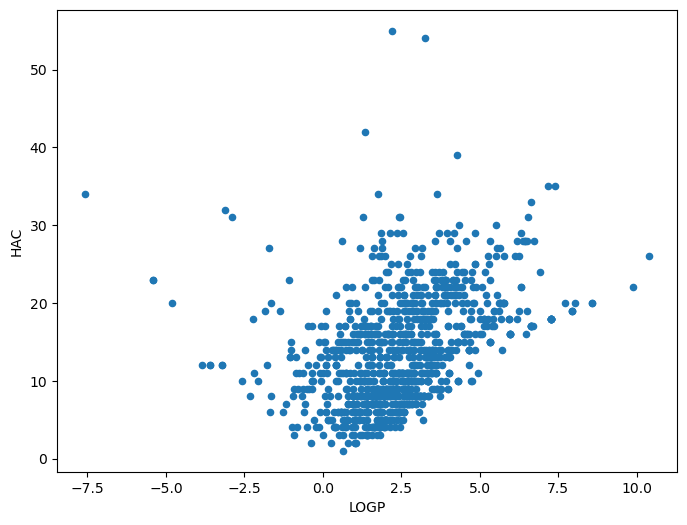

In [36]:
# Check if any of the SMILES contain multiple fragments - 
# this can sometimes cause issues when computing descriptors
num_frags =  solu_df_filtered['SMILES'].apply(lambda smiles: len(Chem.GetMolFrags(Chem.MolFromSmiles(smiles),asMols=True)))
print("Fragments: %s" % num_frags.value_counts())

# First we need to parse the SMILES and create RDKit 'mol' objects 
# this is done using the 'standardize' function that was defined in the first cell with code in this notebook
solu_df_filtered['MOL'] = solu_df_filtered['SMILES'].apply(standardize)


# Compute the descriptors that we're interested in
solu_df_filtered['LOGP'] = solu_df_filtered['MOL'].apply(lambda mol: Descriptors.MolLogP(mol))
solu_df_filtered['HAC'] = solu_df_filtered['MOL'].apply(lambda mol: Descriptors.HeavyAtomCount(mol))




# Plot
hac_logp_fig = solu_df_filtered.plot.scatter(x='LOGP', y='HAC', figsize=fig_size)

In [37]:
solu_df_filtered

,SMILES,Measured,Predicted,MOL,LOGP,HAC
0,BrC(Br)(Br)Br,-3.14,-4.063,<rdkit.Chem.rdchem.Mol object at 0x7fbe40c9b610>,3.1773,5
1,BrC(Br)Br,-1.91,-2.904,<rdkit.Chem.rdchem.Mol object at 0x7fbdeb22bdf0>,2.4547,4
2,BrC(Cl)Cl,-1.54,-2.176,<rdkit.Chem.rdchem.Mol object at 0x7fbdeb22bd80>,2.1425,4
3,BrCBr,-1.17,-1.883,<rdkit.Chem.rdchem.Mol object at 0x7fbdeb22b530>,1.7337,3
4,BrCCBr,-1.68,-2.102,<rdkit.Chem.rdchem.Mol object at 0x7fbdeb22af80>,1.7762,4
...,...,...,...,...,...,...
1121,c2ccc1scnc1c2,-1.50,-2.733,<rdkit.Chem.rdchem.Mol object at 0x7fbdea8e3530>,2.2963,9
1122,c2cnc1ncncc1n2,0.02,-0.906,<rdkit.Chem.rdchem.Mol object at 0x7fbdea8e35a0>,0.4198,10
1123,c3ccc2c(O)c1ccccc1cc2c3,-4.73,-4.148,<rdkit.Chem.rdchem.Mol object at 0x7fbdea8e3610>,3.6986,15
1124,c3ccc2nc1ccccc1cc2c3,-3.67,-3.846,<rdkit.Chem.rdchem.Mol object at 0x7fbdea8e3680>,3.3880,14


Firstly, there are only records of molecules based of single fragments - so no need to filter anything based on this. Secondly, most of molecules are sub 50 HAC and within a fairly close proximity in this plot. We could remove for instance records with molecules with HAC>50 and perhaps a few other *outliers*, but let's not go too deep into this and keep all records as they are. Hopefully they will not influence the results too much, if you're interested you could try that out in the end of the lab! 

We can depict a few of the molecules if we like, to get a feeling for what type of molecules there are in the dataset. Firstly we plot ten random molecules. You may need to tweak the parameters to make all molecules fit on your screen.

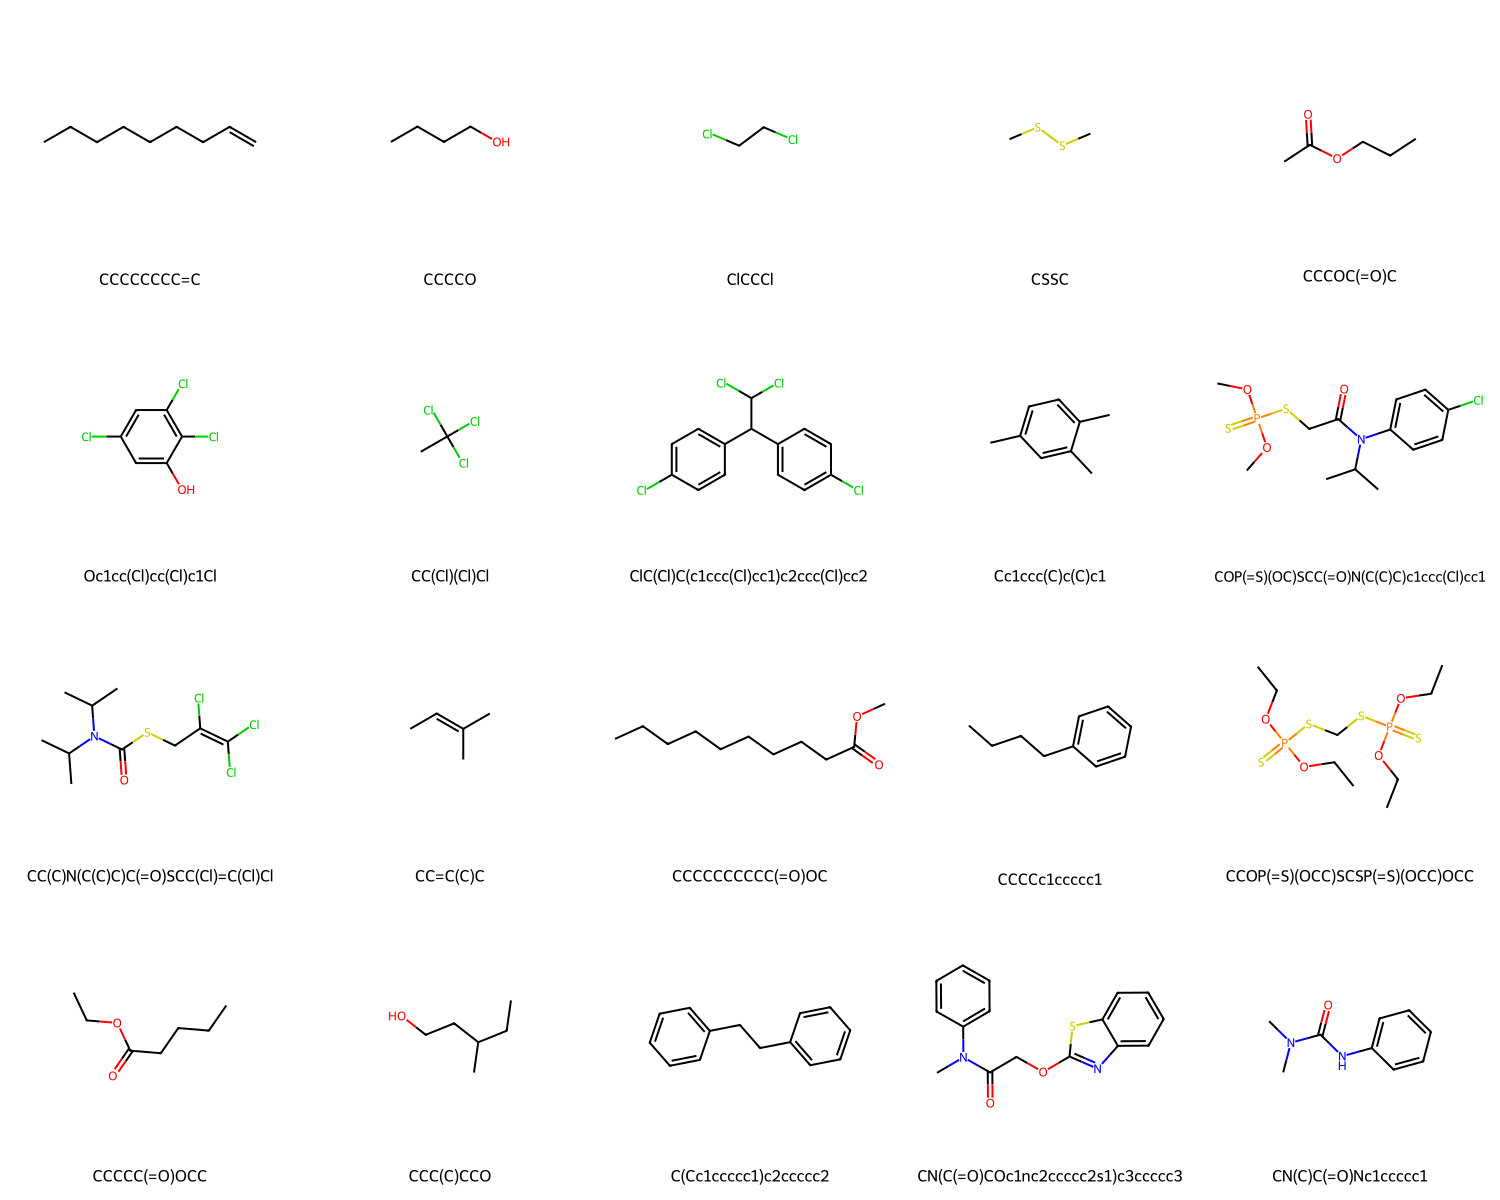

In [38]:
PandasTools.FrameToGridImage(solu_df_filtered.sample(n=20), 
                             column='MOL',
                             legendsCol='SMILES', 
                             molsPerRow=5, 
                             subImgSize=(300, 300)
                            )

These are likely all relatively small and "typical" drug molecules, let us instead depict the HAC > 50 ones!

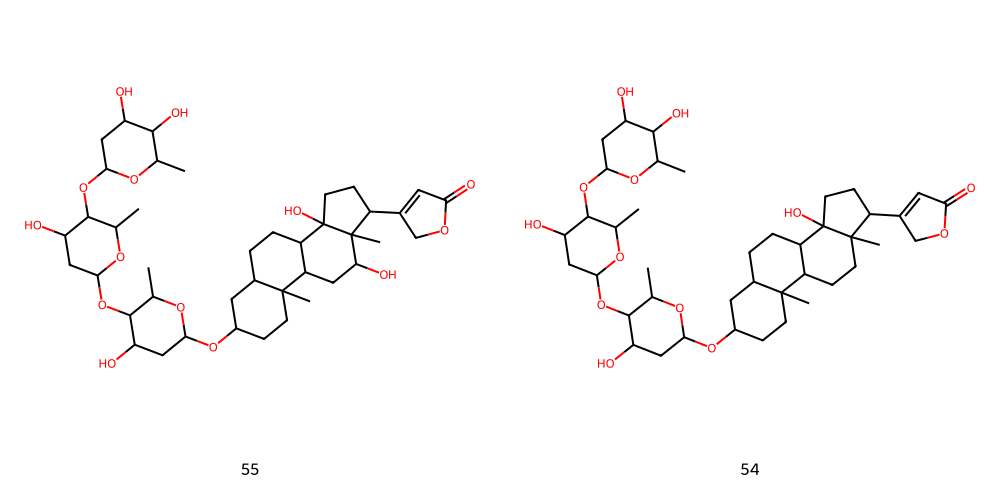

In [39]:
largeMols = solu_df_filtered[solu_df_filtered['HAC']>50]

PandasTools.FrameToGridImage(largeMols, 
                             column='MOL', 
                             legendsCol='HAC', 
                             molsPerRow=2, 
                             subImgSize=(500, 500))

There are only two molecules with HAC>50 and they have a very similar structure, only differing with a single hydroxyl (OH) group. With this in mind you may consider what implications this could have to the evaluation of the models and how typical QSAR and chemical modeling may differ from other fields employing supervised modeling. **Take a moment to think about this before checking below.**

<details>
<summary>
    <b>Answer:</b>
</summary>
    The answer to this is twofold; 
    <ul>
        <li> For the evaluation of the model there are three possible senarios (1) both molecules are in the training set, (2) one of the molecules is in the training set and one is in the evaluation and, (3) both are in the evaluation set. For case (1) there are no 'strange' molecules in the evaluation set and the inclusion of these molecules in the data set does not affect the "test score", (2) the model is trained with at least one molecule that is very similar and is more likely producing a good prediction for the test-molecule and, (3) the model has not seen any molecules of this size and will thus be less likely to produce a good prediction and the test score is likely worse. Thus already here we can see one of the merits of using some repeated type of test-evaluation like <i>k</i>-fold CV. </li>
        <li> These molecules are very similar in structure, most likely due to the typical drug discovery process - were a drug lead is first found and small chemical modifications are applied on order to optimize other properties such as toxicity, ADMET properties etc later in the process. Very similar molecules are thus frequently tested in assays. On the other hand, all standard machine learning algorithms impose the assumption of data being <b>Independent and Identically distributed (IID)</b>. This is mostly overlooked within QSAR/QSPR modeling but is something that should be kept in mind - if you have clusters of very similar compounds (lead compounds and small alterations of them) and divide these randomly between training and testing sets, perhaps the generalized error produced might not truely reflect how well the model will perform for completely independent test molecules. This reasoning is however rather complex and somewhat out of the scope of this introductory course, do not worry if you do not understand it - but feel free to ask if you find it interesting.</li>
    </ul>
    
</details>

It is also good to have an understanding of the distribution of the measured values, so we can e.g. relate RMSE and MSE to the magnitude of what we are modeling.  
**Tasks:** 
<ol>
    <li>Plot the distribution of the measured values (found in column <code>solu_df_filtered['Measured']</code>)<a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.density.html"> Click here for help</a></li>
    <li>Find the mean and median of these values. </li>
</ol>
Fill in your solution in the cell below.

-3.042790408525755 -2.855


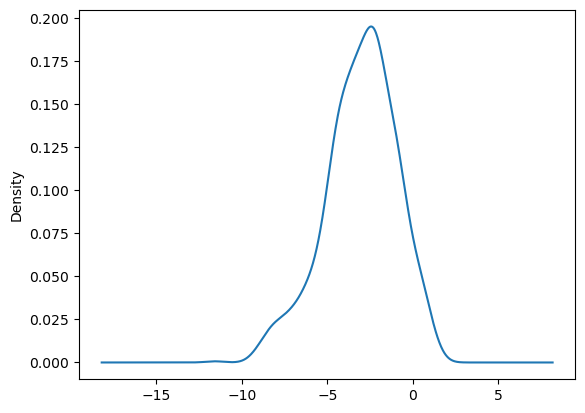

In [40]:
# TODO - plot distribution of values
pandas_plot = solu_df_filtered['Measured'].plot.kde()
mean_value = solu_df_filtered['Measured'].mean()
median_value = solu_df_filtered['Measured'].median()
print (mean_value, median_value)

In [41]:
# Locked cell for grading

## 2. Similarity matching

OK! Let's say that we're happy with our dataset and move on. There are two widely used fingerprint types in RDKit; the RDKits own fingerprinter and the Morgan fingerprint. Both are hashed fingerprints and we can choose the number of bits we wish to use, let us use 2048 bits for the RDKit and 1024 for Morgan finterprints and default settings for the rest. Morgan fingerprints use a single circular radius, typically 2 is the normal to use, whereas the RDKit uses several radiuses (default is 1 to 7). This is why we can get away with fewer bits for the Morgan fingerprint, there are simply less possible fragments and thus less chance for collisions in the hashing function. The fingerprints are bit-vectors (i.e. vectors of a fixed length with either 0 or 1 in each index), and they need to be converted into numpy ndarray objects for the analysis in the next section where we use them for ML modeling. 

In [42]:
# Parameters
morgan_radius = 2
morgan_n_bits = 1024
fp_n_bits = 2048

# generate Morgan fingerprint with radius 2
morgan_fp = [AllChem.GetMorganFingerprintAsBitVect(m, morgan_radius, nBits=morgan_n_bits) for m in solu_df_filtered['MOL']]
# convert the RDKit explicit vectors into numpy arrays
X_morgan = np.asarray(morgan_fp)

# generate RDKFingerprint with default settings
rdkit_fp = [Chem.RDKFingerprint(m, fpSize=fp_n_bits) for m in solu_df_filtered['MOL']]
# convert the RDKit explicit vectors into numpy arrays
X_rdkit = np.asarray(rdkit_fp)

# Get the target values 
y = solu_df_filtered['Measured'].to_numpy()



Before using traditional machine learning methods for modeling, we could build our own simplified prediction model by generating a 1-NN predictor ([k-nearest neighbour](https://scikit-learn.org/stable/modules/neighbors.html), using only a single neighbour) using fingerprint similarity. We can make things simple by splitting the data into two separate sets, one for training and one for testing. Then we make predictions by finding the most similar fingerprint in the training set and returning the value recorded for that molecule (or average if several molecules have the same tanimoto similiarity). Tanimoto similarity measures how similar two molecular fingerprints are.  


Look through the code below and make sure you understand it.  
**Task:** Fill in the line marked with `#TODO`, **hint:** you could use e.g. the [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function from sklearn.


FP-similarity based predictions, MSE: 1.935


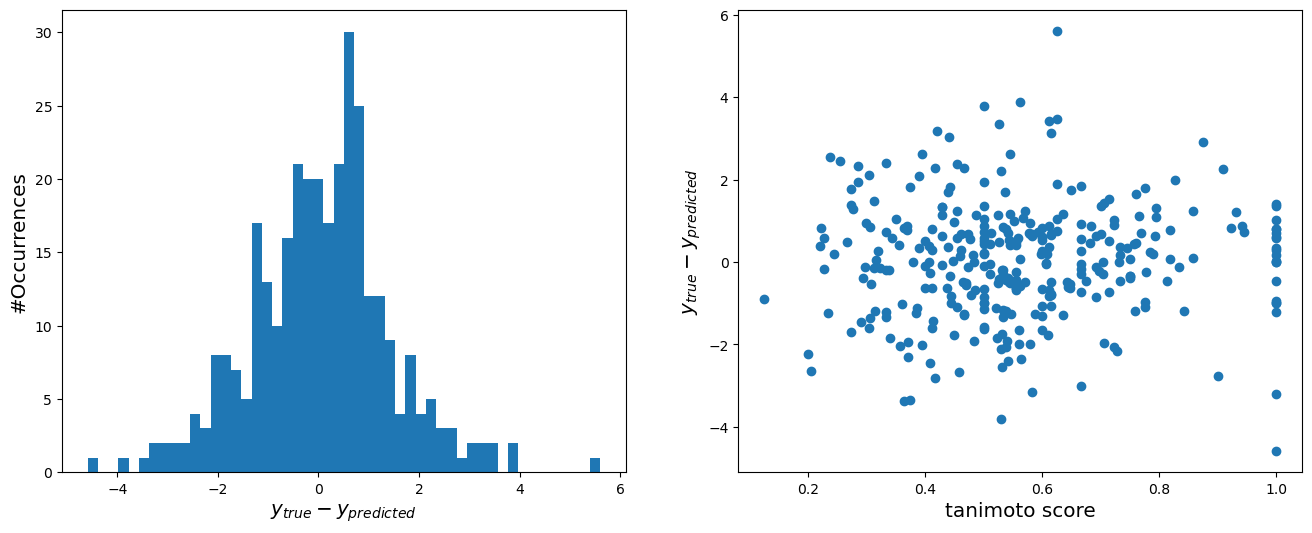

In [43]:
# Take a random partition of the dataset, say 800 molecules for basing predictions (training)
# and the remaining for testing
n_training = 800
rng_seed = 1513510 # Random seed for reproducibility

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(morgan_fp,
                                                    y,
                                                    train_size=n_training,
                                                    shuffle=True,
                                                    random_state=rng_seed) # TODO - FILL IN

# Define a function that performs the 'similarity based predictions'
def predict_based_on_tanimoto(fp):
    '''Return tuple (best-tanimoto-score, y-predicted)'''
    best_tani = -1
    best_tani_ind = []
    for ind, fp_mol in enumerate(X_train):
        tani = DataStructs.FingerprintSimilarity(fp_mol, fp) # tanimoto similarity between fp and the current training fingerprint
        #TODO (pseudo code below
        # if similarity (variable tani) is higher than the best (variable best_tani) so far:
            # update best_tani
            # store current index:  best_tani_index = [ind]
        # else if similarity equals the best so far:
            # add current index to list : append to best_tani_index
        # YOUR CODE HERE
        if tani > best_tani:
            best_tani = tani
            best_tani_ind = [ind]
        
        elif tani == best_tani:
            best_tani_ind.append(ind)

        #raise NotImplementedError()
        
    # return the tanimoto score and the mean of the measurement from training examples with the
    # highest tanimoto score
    return best_tani, np.mean(y_train[best_tani_ind])

# Loop through all test molecules and predict!
n_test = len(y_test)

y_test_preds = np.zeros(n_test)
test_tani_scores = np.zeros(n_test)
for i in range(n_test):
    
    #TODO
    # predict tanimoto using the above function of each samples in X_test and store the tanimoto score
    # in test_tani_scores and mean score in y_test_preds
    # hint - you can access/modify elements in an array using its index eg: test_tani_scores[i]
    # YOUR CODE HERE

    tani, pred = predict_based_on_tanimoto(X_test[i])
    test_tani_scores[i] = tani
    y_test_preds[i] = pred
    #raise NotImplementedError()

diff_solu = y_test-y_test_preds

# Plot and visualize the results
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(fig_size[0]*2,fig_size[1]))
# Histogram over differences
ax1.hist(diff_solu, bins=50)
ax1.set_xlabel('$y_{true} - y_{predicted}$',fontsize='x-large')
ax1.set_ylabel('#Occurrences',fontsize='x-large')

# Scatter plot of similarity vs the prediction-errors
ax2.scatter(test_tani_scores, diff_solu)
ax2.set_xlabel('tanimoto score',fontsize='x-large')
ax2.set_ylabel('$y_{true} - y_{predicted}$',fontsize='x-large') #_{predicted

print("FP-similarity based predictions, MSE: %.3f" % mean_squared_error(y_test_preds, y_test))

Here we used the Tanimoto similarity between fingerprints (the default used in `DataStructs.FingerprintSimilarity`), does the prediction accuracy change if you change the similarity metric? Now we used the Morgan fingerprint, does it change if you use the RDKit fingerprint? **Question: do you see any trend in the plot to the right? If so, is the trend what you would expect?**
      
<details>
<summary>
<b>Answer:</b>
</summary>
    The key idea of QSAR/QSPR is that similar molecules have similar chemical and biological properties. Thus we expect that a higher tanimoto score (higher degree of similarity) would result in better predictions. There is an overall trend, albeit rather weak, that the <i>y<sub>true</sub> - y<sub>predicted</sub></i> is closer to 0 for the higher tanimoto score, except for the molecules at tanimoto = 1.0, were the errors span quite a large range of prediction errors.
    <br>
    Further, if you replace the <code>morgan_fp</code> with <code>rdkit_fp</code> this trend is no longer seen, which is something that we wouldn't expect. Perhaps the RDKit fingerprint is worse when used as descriptor for QSAR? 
    
</details>
</br>

In this section we used the fingerprint similarity for predicting the solubility for an "unknown" molecule. This is QSAR in a nutshell, we assume that the structure of a molecule is related to the property that we are trying to predict. 

## 3. Evaluate fingerprint descriptors

Now let's continue with QSAR and use some of the more typically used learning algorithms. First we define an evaluation function that computes the MSE (so we can compare with the results they got in the paper we are using data from). Here we will use the same [k-fold CV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) as in the supervised excercise, in conjunction with the [mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)-function in sklearn.  

**TODO** Write cross validation function [from sckit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)

In [44]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer


# Set the Random Number Generator (RNG) seed to make sure you can reproduce your results (feel free to change this!)
seed = 42

cv_folds = 10
#timer = Stopwatch()
score_func = make_scorer(mean_squared_error, 
                         greater_is_better=False)

# Define a utility method for running k-fold CV 
def eval_estimator(estimator, X, y):
    '''Evaluation function that takes an estimator (regression algorithm) and a design matrix and corresponding target values'''
    start_time = time.time()
    #TODO
    # write a K-fold function from sckit (link in description)
    # Use the parameters number of folds, random state, keep the shuffle parameter = True
    k_fold = KFold(n_splits=cv_folds, random_state=seed, shuffle=True)
    # YOUR CODE HERE
    #raise NotImplementedError()
    
    #TODO
    # Write the cross validation function (link in description) here from the scikit learn.
    # The function will take inputs estimator, X, y, score_func, and
    # k_fold function we defined above (argument cv)
    mse_scores = cross_val_score(estimator, X, y, scoring=score_func, cv = k_fold)
    # YOUR CODE HERE
    #raise NotImplementedError()
    
    stop_time = time.time()
    elapsed_time = stop_time - start_time
    # Flip the sign of the MSE mean value, the make_scorer flips it internally 
    mse_mean = - mse_scores.mean()
    if mse_mean > 100:
        # If we have a really bad MSE - report in exponential format
        print("MSE: %0.3E (+/- %0.3E) runtime: %0.3f s" % (mse_mean, mse_scores.std() * 2, elapsed_time))
    else:
        print("MSE: %0.3f (+/- %0.3f) runtime: %0.3f s" % (mse_mean, mse_scores.std() * 2, elapsed_time))
    return mse_mean


We will start simple by trying a linear model at first. We can try Ordinary Least Squares (OLS) and then also apply L2 and L1 regularization ([Ridge regression: L2 regularization](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) and [Lasso: L1 regularization](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)). 


**Task:** Evaluate both [L2](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) and [L1](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) regularization in the following cells. Use the same `eval_estimator` function as in the first cell.

In [45]:
# Standard OLS linear regression 
if True:
    print("Standard Linear Regression:")
    mse_morgan_lr = eval_estimator(LinearRegression(), X_morgan, y)
    mse_rdkit_lr = eval_estimator(LinearRegression(), X_rdkit, y)

Standard Linear Regression:
MSE: 97.590 (+/- 135.821) runtime: 3.868 s
MSE: 7.828 (+/- 10.319) runtime: 5.406 s


Example output from the above cell:
```
Standard Linear Regression:
MSE: 97.590 (+/- 135.821) runtime: 1.623 s
MSE: 7.828 (+/- 10.319) runtime: 3.061 s 
```

In [46]:
# Using L2 regularization
print("Linear Regression with L2 regularization:")
mse_morgan_l2 =  eval_estimator(Ridge(), X_morgan, y)
mse_rdkit_l2 =  eval_estimator(Ridge(), X_rdkit, y)

Linear Regression with L2 regularization:
MSE: 2.188 (+/- 0.870) runtime: 0.674 s
MSE: 1.957 (+/- 0.835) runtime: 1.001 s


In [47]:
# Using L1 regularization
print("Linear Regression with L1 regularization:")
mse_morgan_l1 =  eval_estimator(Lasso(), X_morgan, y)
mse_rdkit_l1 =  eval_estimator(Lasso(), X_rdkit, y)

Linear Regression with L1 regularization:
MSE: 4.388 (+/- 1.247) runtime: 0.163 s
MSE: 4.388 (+/- 1.247) runtime: 0.503 s


In [48]:
# Locked cell for grading

Wow, using linear regression without regularization was **extremely bad! Question: do you have any idea why?** Note that the regularization results were fairly OK, not as good as the published predictions of around 0.83 but still within reason. **Take a minute to try and come to up with reasons on your own before continuing**. Also compare with the simple 1-NN predictor we used in the section before, even though we cannot strictly compare the results as we did not evaluate it in the same way. 

If you have not come up with a potential reason for why OLS did not work, perhaps trying PLSRegression below might give you a hint. You can read more about PLS-Regression on the sklearn page for [PLSRegression](https://scikit-learn.org/stable/modules/generated/sklearn.cross_decomposition.PLSRegression.html), but the simplified idea of PLSRegression is to combine PCA (to reduce the number of dimensions of the feature-matrix `X`) and applying linear regression on the new `X` matrix with much fewer dimensions. We cannot know the optimal number of dimensions in advance, we could use standard PCA on the X matrix and use the Elbow-method to find a good value to use as good starting point (even though the optimal solution might not be identical). You could do that, or fill in a few values below and find the optimal value using the MSE of the PLS instead. Let us continue with only one of the fingerpints as they produce similar results, you may choose the one of your own liking by replacing the `X_rdkit` to `X_morgan` in the cell below, or keept it as it is. 
  
**Task: replace the "#TODO" with [PLS regression](https://scikit-learn.org/stable/modules/generated/sklearn.cross_decomposition.PLSRegression.html) and pass the number of components to try out to the PLS regression**.

In [49]:
all_pls_mean = []
for comp in range(1,20):
    print("Running PLS-Regression n_components=%d" % comp)
    pls_model = PLSRegression(n_components=comp)

    all_pls_mean.append(eval_estimator(pls_model, X_rdkit, y))
    #TODO - write the eval estimator for the above PLS model. This will append the output of the eval_estimator to the all_pls_mean list

Running PLS-Regression n_components=1
MSE: 3.685 (+/- 1.147) runtime: 0.475 s
Running PLS-Regression n_components=2
MSE: 2.350 (+/- 1.039) runtime: 0.587 s
Running PLS-Regression n_components=3
MSE: 1.890 (+/- 0.902) runtime: 0.682 s
Running PLS-Regression n_components=4
MSE: 1.732 (+/- 0.883) runtime: 0.810 s
Running PLS-Regression n_components=5
MSE: 1.524 (+/- 0.803) runtime: 1.033 s
Running PLS-Regression n_components=6
MSE: 1.429 (+/- 0.787) runtime: 0.966 s
Running PLS-Regression n_components=7
MSE: 1.315 (+/- 0.670) runtime: 1.191 s
Running PLS-Regression n_components=8
MSE: 1.245 (+/- 0.650) runtime: 1.175 s
Running PLS-Regression n_components=9
MSE: 1.191 (+/- 0.576) runtime: 1.420 s
Running PLS-Regression n_components=10
MSE: 1.169 (+/- 0.571) runtime: 1.509 s
Running PLS-Regression n_components=11
MSE: 1.154 (+/- 0.564) runtime: 1.697 s
Running PLS-Regression n_components=12
MSE: 1.172 (+/- 0.579) runtime: 1.605 s
Running PLS-Regression n_components=13
MSE: 1.172 (+/- 0.558)

In [ ]:
# Locked cell for grading

How many dimensions did you find to be optimal? How are you sure that you've actually found the global optima? The best result we found was *MSE: 1.154 (+/- 0.564)*, did you beat that? 

Hopefully by now you have an idea of why the Linear Regression performed so poorly; it is because the feature matrix, X, is made up with a lot of 0s and there is no penalty for large weights. When the algorithm tries to find the optimal parameters, some features might be 0 for all training examples and thus that parameter can end up becoming very large (positive or negative), without having any effect on the training data loss. If the validation/testing data then has examples that happens to have a 1 for any of these parameters the predicted value can become something really large or small, even though values in those ranges has never been encountered before. That is why the the regularization improved the predictions, as it not only tries to find the optimal parameters, but also punishes large parameter values for features. The PLS-regression also effectively removes dimensions where there is no variance (i.e. all training examples had a 0 or 1 for one feature), and thus these features will not end up in the final model.

We can count the number of 0s and 1s in the `X` matrix and examine the model weights to validate this!

In [50]:
unique_elements, counts_elements = np.unique(X_morgan, return_counts=True)

print("Number of 0s vs 1s:")
for i in [0,1]:
    print("{0}: {1}".format(unique_elements[i], counts_elements[i]))

# Look at the generated weights for the Linear Regression model
# Train the model yourself
bad_model = LinearRegression().fit(X_morgan,y)

w = bad_model.coef_
small_w_mask = [w < -10][0]
small_w  = np.compress(np.asarray(small_w_mask), w)
print("Number of weights smaller than -10: %d" % len(small_w))

large_w_mask = [w > 10][0]
large_w  = np.compress(np.asarray(large_w_mask), w)
print("Number of weights larger than 10: %d" % len(large_w))

normal_w_mask = [w > -10][0][w < 10]
normal_w  = np.compress(np.asarray(normal_w_mask), w)
print("Number of 'normal' weights: %d" % len(normal_w))

print("Regression intercept: %.4f" % bad_model.intercept_)

Number of 0s vs 1s:
0: 1128923
1: 24101
Number of weights smaller than -10: 186
Number of weights larger than 10: 166
Number of 'normal' weights: 672
Regression intercept: -3.2652


Here, we simply took an arbitrarily large number (10) and checked for larger or smaller feature weights. Apparently, many weights are either quite large or very small! Thus, validating models are a crucial step in modeling - you cannot deploy a model without validating and making sure that things work as they should. 

## 4. Evaluate Physicochemical descriptors

OK let us move on! We have tried some standard fingerprints, now we will compute Physicochemical (PhysChem) descriptors as they did in the paper we took the dataset from. They tried 8 descriptors but found that 4 of them were the most significant in the modeling. RDKit has a list of their [available descriptors](https://www.rdkit.org/docs/GettingStartedInPython.html#list-of-available-descriptors). 
The cell below computes all descriptors for you, the first descriptor I had to calculate with a new function but the rest was available right away in RDKit.

In [51]:
from rdkit.Chem import rdMolDescriptors

pat = Chem.MolFromSmarts("[#6]")

def count_carbons(mol):
    return len(mol.GetSubstructMatches(pat))

def calc_proportion_not_carbon(mol):
    n_C = count_carbons(mol)
    n_tot = Descriptors.HeavyAtomCount(mol)
    return (n_tot-n_C)/n_tot

# 1. cLogP - already compted when plotting the HAC vs LogP earlier
#solu_df['LOGP'] = solu_df['MOL'].apply(lambda mol: Descriptors.MolLogP(mol))
# 2. MolWt
solu_df_filtered['Wt'] = solu_df_filtered['MOL'].apply(lambda mol: Descriptors.MolWt(mol))
# 3. NumRotatableBonds
solu_df_filtered['#rb'] = solu_df_filtered['MOL'].apply(lambda mol: Descriptors.NumRotatableBonds(mol))
# 4. NumAromaticRings
solu_df_filtered['#arom'] = solu_df_filtered['MOL'].apply(lambda mol: Descriptors.NumAromaticRings(mol))
# 5. Proportion "not C" / HeavyAtomCount 
solu_df_filtered['prop_not_C'] = solu_df_filtered['MOL'].apply(lambda mol: calc_proportion_not_carbon(mol))
# 6. NumHDonors
solu_df_filtered['#H_donors'] = solu_df_filtered['MOL'].apply(lambda mol: Descriptors.NumHDonors(mol))
# 7. NumHAcceptors
solu_df_filtered['#H_acceptors'] = solu_df_filtered['MOL'].apply(lambda mol: Descriptors.NumHAcceptors(mol))
# 8. Polar Surface Area
solu_df_filtered['PSA'] = solu_df_filtered['MOL'].apply(lambda mol: rdMolDescriptors.CalcTPSA(mol))

solu_df_filtered.head()

,SMILES,Measured,Predicted,MOL,LOGP,HAC,Wt,#rb,#arom,prop_not_C,#H_donors,#H_acceptors,PSA
0,BrC(Br)(Br)Br,-3.14,-4.063,<rdkit.Chem.rdchem.Mol object at 0x7fbe40c9b610>,3.1773,5,331.627,0,0,0.800000,0,0,0.0
1,BrC(Br)Br,-1.91,-2.904,<rdkit.Chem.rdchem.Mol object at 0x7fbdeb22bdf0>,2.4547,4,252.731,0,0,0.750000,0,0,0.0
2,BrC(Cl)Cl,-1.54,-2.176,<rdkit.Chem.rdchem.Mol object at 0x7fbdeb22bd80>,2.1425,4,163.829,0,0,0.750000,0,0,0.0
3,BrCBr,-1.17,-1.883,<rdkit.Chem.rdchem.Mol object at 0x7fbdeb22b530>,1.7337,3,173.835,0,0,0.666667,0,0,0.0
4,BrCCBr,-1.68,-2.102,<rdkit.Chem.rdchem.Mol object at 0x7fbdeb22af80>,1.7762,4,187.862,1,0,0.500000,0,0,0.0


Now we've calculated all eight PhysChem descriptors, we just have to convert them into a numpy ndarray matrix and then we can evaluate them! **Task: Create a numpy feature matrix (X_phys_chem).** Hint: there is a [to_numpy()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html) function that can be called on a Pandas DataFrame instance to convert into a numpy ndarray. The `X_phys_chem` ndarry should only contain the eight descriptors. The ones we have obtained above and the LOGP column, i.e. not the columns SMILES, Measured, etc.

In [53]:
# TODO
selected_columns = ['LOGP','Wt','#rb','#arom','prop_not_C', '#H_donors','#H_acceptors','PSA']

X_phys_chem =  solu_df_filtered[selected_columns].to_numpy()

In [54]:
# Locked cell for grading

### 4.1 Linear regression
Firstly we will try using a low complexity model - linear regression, both a standard ordinary least squares (OLS) regression and L1/L2 regularized regression. 

In [57]:
# Hint: Use the eval_estimator function in the same way as before, 
# except now use the features from the NumPy array defined above.

# Standard OLS linear regression
print("Standard Linear Regression:")
lr_des_mean =  eval_estimator(LinearRegression(), X_phys_chem, y)

# Using L2 regularization
print("Linear Regression with L2 regularization:")
l2_des_mean =  eval_estimator(Ridge(), X_phys_chem, y)

# Using L1 regularization
print("Linear Regression with L1 regularization:")
l1_des_mean = eval_estimator(Lasso(), X_phys_chem, y)

Standard Linear Regression:
MSE: 0.939 (+/- 0.310) runtime: 0.019 s
Linear Regression with L2 regularization:
MSE: 0.939 (+/- 0.311) runtime: 0.016 s
Linear Regression with L1 regularization:
MSE: 1.538 (+/- 0.529) runtime: 0.017 s


In [58]:
# Locked cell for grading

OK, now we're pretty close to the MSE of 0.829 that we calculated based on results from the paper. We might have slightly different descriptors compared to the ones used in the paper and the dataset we used only contained 1126 molecules whereas in the paper they used an exteded dataset with 1305 molecules. They did not use the standard 10-fold CV, instead used 3 separate validation sets based on molecule size (they wished to see if the performance differed between different types of molecules). So minor differences are expected, also consider that we use the MSE for evaluation - i.e. the differences are squared and thus the difference will become larger then e.g. considering the RMSE. 

**Question + Bonus task:** As in the paper, can you deterimine which descriptor was the most important for the prediction? Hint: look at what you did during the supervised lab.

<details>
<summary>
<b>Answer:</b>
</summary>
    For linear regression we can look at the learned coefficients/parameters of the model. However, to get a representative idea of each features contribution we need to scale the features in the same way! Otherwise e.g. the 'MW' feature spans larger values, and thus its weight must be scaled downward to be compared to e.g. the 'prop_not_C' feature that can only span 0..1 values. Generally we need to scale the features in the same way in case the model relies on e.g. gradient descent optimization in order to achieve the best model and/or reduce training time. However, for this small data set with few features the scaling did not impact the model error in our tests. 
    
</details>
</br>

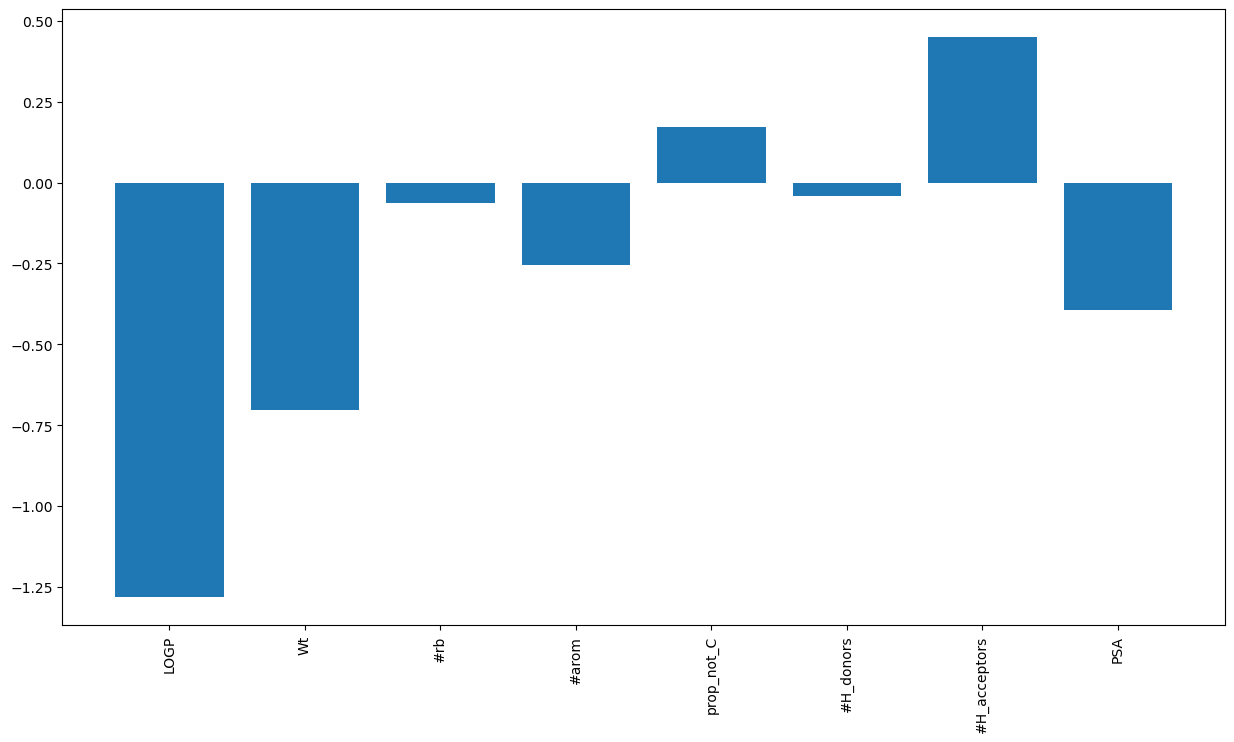

Most (positive) feature: #H_acceptors
Most (negative) feature: LOGP


In [61]:
# Here you can add code for the bonus task
from sklearn.preprocessing import scale

feature_names = ['LOGP','Wt','#rb','#arom','prop_not_C','#H_donors','#H_acceptors','PSA']

# Scale and fit TODO
# Scale the values using scale function
X_sc = scale(X_phys_chem)
# YOUR CODE HERE
#raise NotImplementedError()
# call ridge regression and use lr_l2.fit to fit the model to the scaled data
lr_l2 = Ridge(alpha=1.0)
lr_l2.fit(X_sc, y)
# YOUR CODE HERE
#raise NotImplementedError()

# And plot them
plt.figure(figsize=(15,8))
plt.bar(feature_names,lr_l2.coef_)
plt.xticks(rotation=90)
plt.show()
# Find the most important ones
print("Most (positive) feature: %s\nMost (negative) feature: %s" %
        (feature_names[np.argmax(lr_l2.coef_)], feature_names[np.argmin(lr_l2.coef_)]))

### 4.2 Support Vector Machines
Linear models works well in many cases and ravele some advantages over more complex models, but they cannot model non-linearity without manually constructing such features. Now let us try a more complex model, that can capture non-linearity in the data, here using a Support Vector Machine (SVM) using the popular radial basis (RBF) kernel. SVMs are more sensitive in the choice of hyperparameters (cost value and kernel-parameters) so we need to try out several values in order to find hyperparameters that work well for our particular data. Here *tuning* of hyperparameters is done in a grid-search of possible combinations of hyperparameters. But, both as this is rather time consuming (new models are trained from each combination of parameters) and to get a final, unbiased, generalization error we make a split of data into a withheld test-set and a training set that is used in the tuning. Further note that SVMs require the features to be scaled in order to work optimally so we need to scale them appropriately. 

This cell can take a bit of time to run using your pods, so you may take a break while it is running. Here's a question to think about while waiting for it to complete.  
  
**Question**: How many models will the cell below train, and how do these relate to the two parameters `n_grid_steps` and `k` defined in the cell?

<details>
<summary>
<b>Answer:</b>
</summary>
    The number of models trained and evaluated in the grid search is: <TT>n_grid_steps * n_grid_steps * k = 180</TT>
</details>
</br>

In [63]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

n_grid_steps = 6
k = 5 # Number of folds in k-Fold CV
validation_proportion = .25

# Split into test and train
X_train, X_test, y_train, y_test = train_test_split(X_phys_chem, y, 
                                                    shuffle=True, 
                                                    random_state=seed, 
                                                    test_size=validation_proportion)
# Scale features
scaler = StandardScaler()
#TODO
# Scale using fit_transform
X_train_scaled = scaler.fit_transform(X_train)
# YOUR CODE HERE
#raise NotImplementedError()
# Use same scale factors as above to scale the test data (hint: don't fit again)
X_test_scaled = scaler.transform(X_test)
# YOUR CODE HERE
#raise NotImplementedError()

# Create the grid of hyperparameters to pick, feel free to change these
grid_params = {'kernel': ['rbf'], 
              'gamma': np.logspace(-2,-7, base=2, endpoint=True, num=n_grid_steps),
              'C': np.logspace(0,3, base=10, endpoint=True, num=n_grid_steps)}

# Define the testing strategy that should be used in the grid-search
test_strategy = KFold(k, shuffle=True, random_state=seed)

start_time = time.time()
grid_search = GridSearchCV(
        SVR(), grid_params, scoring='neg_mean_squared_error', cv=test_strategy)
grid_search.fit(X_train_scaled, y_train) # Only use the train data 
stop_time = time.time()
elapsed_time = stop_time - start_time
print(grid_search.best_params_)
print("Best (CV-score) MSE: %.3f" % (-1*grid_search.best_score_))
print("Time for doing grid-search: %s" % elapsed_time)

{'C': 63.0957344480193, 'gamma': 0.03125, 'kernel': 'rbf'}
Best (CV-score) MSE: 0.506
Time for doing grid-search: 32.548999309539795


In this cell make a fairly coarse grained grid of parameters to try out but the results should be much better than what we achieved with the linear models tried earlier. However, the *train set* metric is biased due to picking the best hyperparameters from what the test sets tells us. So that's why we withholded a proportion of the data to get a generalized error (i.e. something more reflecting the performance we expect to see on future, unseen, predictions). So let us predict that test set.

In [64]:
# Use the optimal parameters and train using the training data proportion
svr = SVR().set_params(**grid_search.best_params_).fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)
print("MSE (test set): %.3f" % mean_squared_error(y_test,y_pred))

MSE (test set): 0.438


Note that this metric might even be better than the best one produced in the grid search. **Question**: How could this error be lower than what was achieved from the grid search? How does this relate to the *training error*?

<details>
<summary>
<b>Answer:</b>
</summary>
    <ol>
        <li>
            Simply put, the errors made in machine learning models are inversely related to the amount of data you have - i.e. when adding more data we can build better models. When running the grid search we used a 5-fold CV strategy and thus only using 80% of the <i>training data</i> for each fold, and computing the error based on 20% of the <i>training data</i>. The final evaluation on the <i>test data</i> was instead performed on 25% of the inital data set. So comparing the two scenario we both increase the amount of training data, <i>and</i> compute the metric based on more test examples. 
        </li>
        <li>
            We know that the <i>training error</i> should always be smaller than the <i>generalization error</i>, the training error of the final model is e.g. found by running the following code: <TT>mean_squared_error(y_train,svr.predict(X_train_scaled))</TT>. 
        </li>
    </ol>
    
</details>
</br>

**Task: Compute the *training error* in the cell below**

In [65]:
train_error =  mean_squared_error(y_train,svr.predict(X_train_scaled))

train_error

0.3562104713427169

In [66]:
# Locked cell for grading


### 4.3 Random forest
Now let us also try a rule based model. Here we try the popular Random Forest algorithm and initially run with the default settings except for doubling the number of trees (adding more trees typically never result in less accurate models, but do take a longer time to train and predict). Here we evaluate both using the 10-fold CV and the same train-test splits used in the SVM.  

Note: You should get an MSE < 0.45

In [67]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200)

print("RF phys-chem (10-fold CV)")
eval_estimator(rf, X_phys_chem,y)

#TODO

rf_fit = rf.fit(X_train, y_train)
y_rf_predicted = rf_fit.predict(X_test)

rf_mse_error = mean_squared_error(y_test,y_rf_predicted)
print("RF MSE (test set): %.3f" % mean_squared_error(y_test,y_rf_predicted))

RF phys-chem (10-fold CV)
MSE: 0.468 (+/- 0.200) runtime: 8.614 s
RF MSE (test set): 0.398


In [68]:
# Locked cell for grading

For us this produced even better results than the SVM model. If you have time you can try to come up with better values for the hyperparameters to see if you can achieve an even better score. Use e.g. the [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) class that we used for the SVM model, and pick values based on the [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) user manual for different values to test out. 

### Lab finished

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [15]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading

In [ ]:
# Locked cell for grading